# PINN-MLP y PINN-KAN: Ecuación de Poisson 1D
## Fundamento Teórico, Matemático e Implementación Completa

---

## 1. El Problema: Ecuación de Poisson 1D

Resolvemos la ecuación diferencial ordinaria de segundo orden (también llamada ecuación de Poisson en 1D):

$$\frac{d^2 u}{dx^2} = -\sin(x), \quad x \in [0, \pi]$$

con **condiciones de contorno de Dirichlet homogéneas**:

$$u(0) = 0, \qquad u(\pi) = 0$$

La **solución analítica exacta** es $u(x) = \sin(x)$, verificable por sustitución directa:
$u_{xx} = -\sin(x)$ ✓, $u(0)=0$ ✓, $u(\pi)=0$ ✓.

Esta ecuación es el "Hola Mundo" de las EDPs: lineal, con solución conocida, lo que permite cuantificar el error del modelo neuronal con precisión absoluta.

---

## 2. Physics-Informed Neural Networks (PINN)

### 2.1 Idea Central

Una **PINN** es una red neuronal cuya función de pérdida incorpora tanto la **ecuación diferencial** como las **condiciones de contorno**. En lugar de minimizar solo el error de ajuste sobre datos, minimizamos el **residuo de la EDP**:

$$\mathcal{L}(\theta) = \underbrace{\frac{1}{N}\sum_{i=1}^{N} \left[\mathcal{N}[u_\theta](x_i)\right]^2}_{\mathcal{L}_{\text{PDE}}}$$

donde $\mathcal{N}[u]$ es el operador diferencial de la EDP. En nuestro caso: $\mathcal{N}[u] = u_{xx} + \sin(x)$.

### 2.2 Imposición Exacta de las Condiciones de Contorno

En lugar de añadir $\mathcal{L}_{\text{CC}} = u(0)^2 + u(\pi)^2$ a la pérdida (enfoque *soft*, que no garantiza $u(0)=u(\pi)=0$ exactamente), usamos una **arquitectura que impone las CC por construcción**:

$$u_\theta(x) = \underbrace{x(\pi - x)}_{\text{máscara}} \cdot \hat{u}(x; \theta)$$

donde $\hat{u}(x;\theta)$ es la salida *cruda* de la red neuronal y la máscara $m(x) = x(\pi-x)$ garantiza:
- $m(0) = 0 \cdot \pi = 0$ → $u_\theta(0) = 0$ ✓
- $m(\pi) = \pi \cdot 0 = 0$ → $u_\theta(\pi) = 0$ ✓

**Derivadas de la función compuesta** (necesarias para evaluar la EDP):

$$u_x = \hat{u}_x \cdot m(x) + \hat{u} \cdot m'(x), \quad m'(x) = \pi - 2x$$

$$u_{xx} = \hat{u}_{xx} \cdot m(x) + 2\,\hat{u}_x \cdot m'(x) + \hat{u} \cdot m''(x), \quad m''(x) = -2$$

Este enfoque elimina completamente $\mathcal{L}_{\text{CC}}$, la función de pérdida se reduce a $\mathcal{L} = \mathcal{L}_{\text{PDE}}$, y el entrenamiento no necesita equilibrar dos términos en pugna.

---

## 3. Arquitectura PINN-MLP

### 3.1 Definición de la Red

Usamos un **perceptrón multicapa** (MLP) de una capa oculta con $H=20$ neuronas y función de activación $\tanh$:

$$z_j(x) = W_j \cdot x + b_j, \quad j = 1, \ldots, H$$
$$a_j(x) = \tanh(z_j(x))$$
$$\hat{u}(x; \theta) = \sum_{j=1}^{H} V_j \cdot a_j(x) = \mathbf{a}(x) \cdot \mathbf{V}$$

**Parámetros libres** $\theta = \{W, b, V\}$:

| Parámetro | Forma | Significado físico |
|-----------|-------|--------------------|
| $W \in \mathbb{R}^{1 \times H}$ | $(1, H)$ | Pesos de entrada; controlan la "frecuencia" de cada neurona |
| $b \in \mathbb{R}^{1 \times H}$ | $(1, H)$ | Sesgos; desplazan el punto de inflexión de cada neurona |
| $V \in \mathbb{R}^{H \times 1}$ | $(H, 1)$ | Pesos de salida; combinación lineal de las activaciones |

### 3.2 Derivadas Analíticas de $\tanh$

Definimos las siguientes abreviaturas para las derivadas de $\tanh$, usadas repetidamente:

$$\tanh'(z) = \text{sech}^2(z) = 1 - \tanh^2(z) \equiv a'$$
$$\tanh''(z) = -2\tanh(z)\,\text{sech}^2(z) \equiv a''$$
$$\tanh'''(z) = -2\,\text{sech}^2(z)\,(1 - 3\tanh^2(z)) \equiv a'''$$

**Demostración de** $\tanh'''$: Partiendo de $g(z) = -2\tanh\,\text{sech}^2$:
$$g'(z) = -2[\text{sech}^2 \cdot \text{sech}^2 + \tanh \cdot (-2\,\text{sech}^2 \tanh)] = -2\,\text{sech}^2[\text{sech}^2 - 2\tanh^2]$$
$$= -2(1-a^2)[(1-a^2) - 2a^2] = -2(1-a^2)(1-3a^2)$$

### 3.3 Forward Pass: Predicción y Derivadas de $\hat{u}$

$$\hat{u}(x_i) = \mathbf{a}_i \cdot \mathbf{V} = \sum_j V_j a_{ij}$$

$$\hat{u}_x(x_i) = \sum_j V_j \, a'_{ij} \, W_j$$

$$\hat{u}_{xx}(x_i) = \sum_j V_j \, a''_{ij} \, W_j^2$$

En notación matricial (con filas = puntos, columnas = neuronas):

$$\hat{u} = \mathbf{a}\mathbf{V}, \quad \hat{u}_x = (\mathbf{a}' \odot W)\mathbf{V}, \quad \hat{u}_{xx} = (\mathbf{a}'' \odot W^2)\mathbf{V}$$

donde $\odot$ denota producto elemento a elemento y el broadcasting actúa sobre $(N, H) \odot (1, H)$.

La función enmascarada y sus derivadas son:
$$u = \hat{u} \cdot m, \quad u_x = \hat{u}_x m + \hat{u} m', \quad u_{xx} = \hat{u}_{xx} m + 2\hat{u}_x m' + \hat{u} m''$$

### 3.4 Gradientes del Residuo PDE

El residuo es $R = u_{xx} - f(x)$ con $f = -\sin(x)$. La pérdida es $\mathcal{L} = \frac{1}{N}\sum_i R_i^2$.

Por la regla de la cadena: $\frac{\partial \mathcal{L}}{\partial \theta} = \frac{2}{N}\sum_i R_i \cdot \frac{\partial u_{xx}(x_i)}{\partial \theta}$

Y $\frac{\partial u_{xx}}{\partial \theta} = \frac{\partial \hat{u}_{xx}}{\partial \theta} \cdot m + 2\frac{\partial \hat{u}_x}{\partial \theta} \cdot m' + \frac{\partial \hat{u}}{\partial \theta} \cdot m''$.

**Respecto a $V_j$** (V aparece linealmente en $\hat{u}$):
$$\frac{\partial \hat{u}}{\partial V_j} = a_j, \quad \frac{\partial \hat{u}_x}{\partial V_j} = a'_j W_j, \quad \frac{\partial \hat{u}_{xx}}{\partial V_j} = a''_j W_j^2$$

$$\Rightarrow \frac{\partial u_{xx}}{\partial V_j} = a''_j W_j^2 \cdot m + 2a'_j W_j \cdot m' + a_j \cdot m''$$

**Respecto a $b_j$** ($\partial z_j/\partial b_j = 1$, tercera derivada necesaria):
$$\frac{\partial \hat{u}}{\partial b_j} = V_j a'_j, \quad \frac{\partial \hat{u}_x}{\partial b_j} = V_j a''_j W_j, \quad \frac{\partial \hat{u}_{xx}}{\partial b_j} = V_j a'''_j W_j^2$$

$$\Rightarrow \frac{\partial u_{xx}}{\partial b_j} = V_j\left[a'''_j W_j^2 m + 2a''_j W_j m' + a'_j m''\right]$$

**Respecto a $W_j$** ($\partial z_j/\partial W_j = x$, regla del producto doble):
$$\frac{\partial \hat{u}}{\partial W_j} = V_j a'_j x$$
$$\frac{\partial \hat{u}_x}{\partial W_j} = V_j(a'_j + W_j x\, a''_j) \quad \text{[producto: }W_j\text{ en }a'_j\text{ y explícito]}$$
$$\frac{\partial \hat{u}_{xx}}{\partial W_j} = V_j(2W_j a''_j + W_j^2 x\, a'''_j)$$

$$\Rightarrow \frac{\partial u_{xx}}{\partial W_j} = \left[\frac{\partial \hat{u}_{xx}}{\partial W_j} m + 2\frac{\partial \hat{u}_x}{\partial W_j} m' + \frac{\partial \hat{u}}{\partial W_j} m''\right]$$

### 3.5 Actualización de Parámetros (Descenso de Gradiente)

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

con tasa de aprendizaje $\eta = 0.005$ uniforme para todos los parámetros (la arquitectura MLP tiene gradientes de escala homogénea).

---

## 4. Arquitectura PINN-KAN (Gaussian RBF)

### 4.1 El Teorema de Kolmogorov-Arnold (1957)

El teorema de representación de Kolmogorov-Arnold afirma que **toda función continua multivariable** puede descomponerse como composición finita de funciones univariables continuas:

$$f(x_1, \ldots, x_n) = \sum_{q=0}^{2n} \Phi_q\!\left(\sum_{p=1}^{n} \phi_{q,p}(x_p)\right)$$

donde cada $\phi_{q,p}: \mathbb{R} \to \mathbb{R}$ y $\Phi_q: \mathbb{R} \to \mathbb{R}$ son funciones univariables. La implicación arquitectónica es profunda: **no son los nodos los que deben tener no-linealidades, sino las aristas (conexiones)**. Los nodos solo suman.

$$\boxed{\text{MLP: activaciones fijas en nodos} \qquad \text{KAN: activaciones aprendibles en aristas}}$$

### 4.2 Implementación con Funciones de Base Gaussianas (GRBFs)

En lugar de los B-splines del artículo original (Liu et al., 2024), usamos **funciones de base radial gaussianas** (GRBF), que capturan el mismo espíritu: la función de activación en cada arista tiene **forma ajustable mediante parámetros aprendibles**:

$$\phi_j(x; \mu_j, \sigma_j) = \exp\!\left(-\frac{(x - \mu_j)^2}{2\sigma_j^2}\right) = \exp\!\left(-\frac{z_j^2}{2}\right), \quad z_j = \frac{x - \mu_j}{\sigma_j}$$

La predicción es la **suma ponderada** de estas funciones:

$$\hat{u}(x) = \sum_{j=1}^{H} C_j \cdot \phi_j(x) = \boldsymbol{\phi}(x) \cdot \mathbf{C}$$

### 4.3 Tabla de Parámetros KAN

| Parámetro | Forma | Significado geométrico |
|-----------|-------|------------------------|
| $C_j \in \mathbb{R}$ | $(H, 1)$ | Amplitud de la $j$-ésima gaussiana: cuánto contribuye |
| $\mu_j \in \mathbb{R}$ | $(1, H)$ | Centro de la $j$-ésima gaussiana: dónde está en $x$ |
| $\sigma_j > 0$ | $(1, H)$ | Anchura de la $j$-ésima gaussiana: cuánto se extiende |

La arquitectura KAN es **más interpretable** que la MLP: cada $\phi_j$ es una "función de base localizada" centrada en $\mu_j$ con ancho $\sigma_j$. La red aproxima $u(x)$ como superposición de campanas gaussianas desplazables y escalables.

### 4.4 Derivadas de $\phi_j(x)$ respecto a $x$

Las derivadas espaciales son necesarias para evaluar la EDP. Con $z_j = (x-\mu_j)/\sigma_j$:

$$\frac{\partial \phi_j}{\partial x} = \phi_j \cdot \frac{-z_j}{\sigma_j}$$

$$\frac{\partial^2 \phi_j}{\partial x^2} = \frac{\partial}{\partial x}\!\left[\phi_j \cdot \frac{-z_j}{\sigma_j}\right] = \frac{-1}{\sigma_j}\left[\frac{\partial \phi_j}{\partial x} z_j + \phi_j \frac{1}{\sigma_j}\right] = \phi_j \cdot \frac{z_j^2 - 1}{\sigma_j^2}$$

El forward pass KAN, análogamente al MLP con máscara:
$$\hat{u}_x = \boldsymbol{\phi}_x \mathbf{C}, \quad \hat{u}_{xx} = \boldsymbol{\phi}_{xx} \mathbf{C}$$
$$u = \hat{u} \cdot m, \quad u_x = \hat{u}_x m + \hat{u} m', \quad u_{xx} = \hat{u}_{xx} m + 2\hat{u}_x m' + \hat{u} m''$$

### 4.5 Derivadas de $\phi_j$ respecto a los Parámetros

Para el backward pass necesitamos las derivadas de $\phi_j$, $\partial_x\phi_j$ y $\partial_{xx}\phi_j$ respecto a $\mu_j$ y $\sigma_j$.

**Notación:** $\partial_\mu \equiv \partial/\partial\mu_j$, con $\partial z/\partial\mu = -1/\sigma$.

#### Respecto a $\mu_j$:

$$\partial_\mu \phi_j = \phi_j \cdot \frac{z_j}{\sigma_j}$$

$$\partial_\mu (\partial_x \phi_j) = \partial_\mu\!\left[\phi_j \cdot \frac{-z_j}{\sigma_j}\right] = -\frac{1}{\sigma_j}\!\left[\phi_j\frac{z_j}{\sigma_j} z_j + \phi_j \cdot \frac{-1}{\sigma_j}\right] = \phi_j\cdot\frac{1-z_j^2}{\sigma_j^2}$$

$$\partial_\mu (\partial_{xx} \phi_j) = \partial_\mu\!\left[\phi_j\frac{z_j^2-1}{\sigma_j^2}\right] = \frac{1}{\sigma_j^2}\!\left[\phi_j\frac{z_j}{\sigma_j}(z_j^2-1) + \phi_j\cdot\frac{2z_j\cdot(-1/\sigma_j)}{1}\right] = \phi_j\cdot\frac{3z_j - z_j^3}{\sigma_j^3}$$

#### Respecto a $\sigma_j$:

Con $\partial z/\partial\sigma = -z_j/\sigma_j$:

$$\partial_\sigma \phi_j = \phi_j \cdot \frac{z_j^2}{\sigma_j}$$

$$\partial_\sigma (\partial_x \phi_j) = \phi_j \cdot \frac{2z_j - z_j^3}{\sigma_j^2}$$

$$\partial_\sigma (\partial_{xx} \phi_j) = \phi_j \cdot \frac{z_j^4 - 5z_j^2 + 2}{\sigma_j^3}$$

### 4.6 Gradientes KAN de la Pérdida PDE

Con $R = u_{xx} - f(x)$, $\mathcal{L} = \frac{1}{N}\sum R_i^2$:

**Respecto a $C_j$**:
$$\frac{\partial u_{xx}}{\partial C_j} = (\partial_{xx}\phi_j)\,m + 2(\partial_x\phi_j)\,m' + \phi_j\,m''$$

**Respecto a $\mu_j$** (componiendo derivadas espaciales y paramétricas):
$$\frac{\partial \hat{u}_{xx}}{\partial \mu_j} = C_j\,(\partial_\mu\partial_{xx}\phi_j), \quad \frac{\partial \hat{u}_x}{\partial \mu_j} = C_j\,(\partial_\mu\partial_x\phi_j), \quad \frac{\partial \hat{u}}{\partial \mu_j} = C_j\,(\partial_\mu\phi_j)$$
$$\Rightarrow \frac{\partial u_{xx}}{\partial \mu_j} = \frac{\partial \hat{u}_{xx}}{\partial \mu_j} m + 2\frac{\partial \hat{u}_x}{\partial \mu_j} m' + \frac{\partial \hat{u}}{\partial \mu_j} m''$$

**Respecto a $\log\sigma_j$** (reparametrización para garantizar $\sigma_j > 0$):

Definimos $\log\sigma_j$ como parámetro libre, de modo que $\sigma_j = e^{\log\sigma_j} > 0$ siempre.

Por la regla de la cadena: $\frac{\partial \mathcal{L}}{\partial \log\sigma_j} = \frac{\partial \mathcal{L}}{\partial \sigma_j} \cdot \frac{\partial \sigma_j}{\partial \log\sigma_j} = \frac{\partial \mathcal{L}}{\partial \sigma_j} \cdot \sigma_j$

### 4.7 Inicialización de la KAN

| Parámetro | Inicialización | Justificación |
|-----------|---------------|---------------|
| $C_j$ | $\mathcal{N}(0, 0.01^2)$ | Pequeño pero **no cero**: garantiza gradientes no nulos para $\mu,\sigma$ en la primera iteración |
| $\mu_j$ | `linspace(0, π, H)` | Cobertura uniforme del dominio |
| $\log\sigma_j$ | $0$ → $\sigma_j = 1$ | Anchura inicial razonable; se usa $\log\sigma$ para garantizar $\sigma>0$ |

**Tasas de aprendizaje desacopladas**: Los gradientes de $\mu$ y $\log\sigma$ incluyen factores polinómicos en $z$ (hasta $z^4$) que pueden ser mucho mayores que 1. Se usan tasas más pequeñas para evitar inestabilidad:
- $\eta_C = 0.005$ (gradientes de escala normal)
- $\eta_\mu = \eta_{\log\sigma} = 0.0005$ (gradientes polinomialmente ampliados)


Loss final MLP (Poisson):  4.74e-02
Loss final KAN (Poisson):  1.28e-02
sigma_min = 0.9994, sigma_max = 1.0017  (todas > 0 ✓)


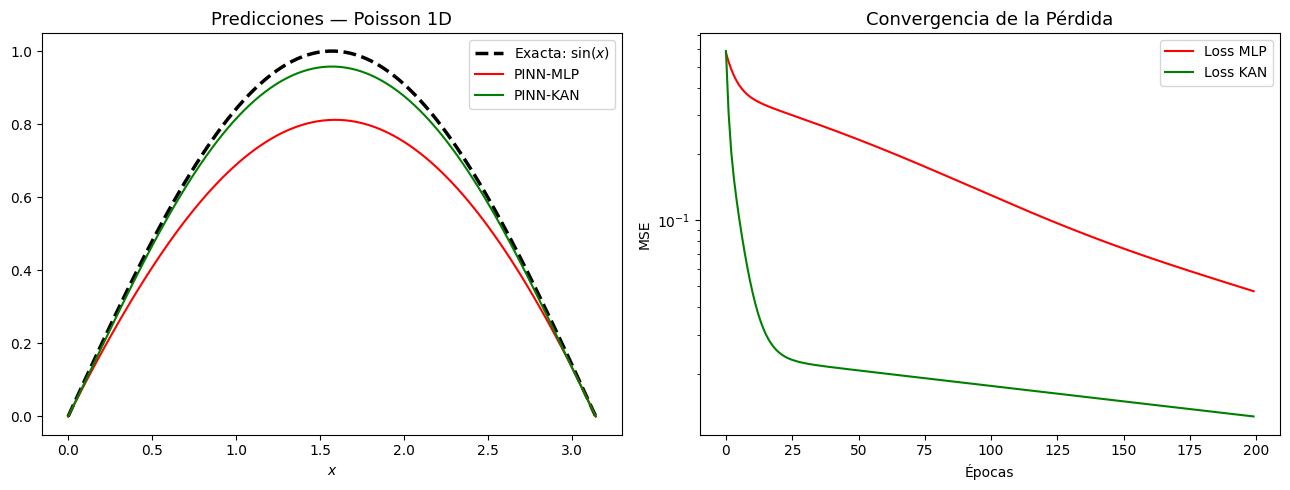

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# PROBLEMA: Poisson 1D — u_xx = -sin(x),  x in [0, pi]
# CC exactas impuestas por arquitectura: u = u_raw * x*(pi-x)
# =============================================================
N = 100
x    = np.linspace(0, np.pi, N).reshape(-1, 1)   # (N,1) colocation points
f_x  = -np.sin(x)                                  # término fuente (N,1)
u_exact = np.sin(x)                                # solución exacta (solo visualización)
epochs = 200
H      = 20                                         # neuronas / funciones de base

# --- Máscara para CCs exactas: m(x) = x*(pi-x) ---
m   = x * (np.pi - x)          # (N,1), m(0)=m(pi)=0
dm  = np.pi - 2.0 * x          # m'(x)
d2m = -2.0 * np.ones_like(x)   # m''(x)

# =============================================================
# SECCIÓN A: PINN-MLP
# =============================================================
np.random.seed(42)
W = np.random.randn(1, H) * 0.1    # (1,H) pesos de entrada
b = np.zeros((1, H))               # (1,H) sesgos
V = np.random.randn(H, 1) * 0.1   # (H,1) pesos de salida
lr_mlp = 0.005
loss_mlp = []

for epoch in range(epochs):
    # ---- FORWARD ----
    z    = x @ W + b              # (N,H) preactivación
    a    = np.tanh(z)             # (N,H) tanh(z)
    ap   = 1.0 - a**2             # (N,H) tanh'  = sech²
    app  = -2.0 * a * ap          # (N,H) tanh'' = -2tanh·sech²
    appp = -2.0 * ap * (1.0 - 3.0*a**2)  # (N,H) tanh''' = -2sech²(1-3tanh²)

    # Derivadas de u_raw (sin máscara)
    u_raw   =  (a)       @ V                    # (N,1)
    ux_raw  =  (ap * W)  @ V                    # (N,1)
    uxx_raw =  (app * W**2) @ V                 # (N,1)

    # Función enmascarada y sus derivadas (regla del producto)
    u_pred  = u_raw  * m                         # (N,1) — BC exacta
    u_x     = ux_raw * m  + u_raw  * dm
    u_xx    = uxx_raw* m  + 2*ux_raw*dm + u_raw*d2m

    # ---- PÉRDIDA (solo PDE, no hay L_BC) ----
    R    = u_xx - f_x             # (N,1) residuo
    L    = np.mean(R**2)
    loss_mlp.append(float(L))

    # ---- BACKWARD ----
    # Bases de derivadas de u_raw, ux_raw, uxx_raw respecto a cada parámetro
    # >> Gradiente respecto a V
    du_dV   = a             # (N,H)  ∂u_raw/∂Vj = aj
    dux_dV  = ap * W        # (N,H)  ∂ux_raw/∂Vj = a'j·Wj
    duxx_dV = app * W**2    # (N,H)  ∂uxx_raw/∂Vj = a''j·Wj²
    d_uxx_dV = duxx_dV*m + 2*dux_dV*dm + du_dV*d2m       # (N,H)
    grad_V = (np.mean(2*R * d_uxx_dV, axis=0, keepdims=True)).T  # (H,1)

    # >> Gradiente respecto a b  [∂z/∂b = 1 → tanh''' aparece en duxx_raw]
    du_db   = V.T * ap              # (N,H)  Vj·a'j
    dux_db  = V.T * app * W        # (N,H)  Vj·a''j·Wj
    duxx_db = V.T * appp * W**2    # (N,H)  Vj·a'''j·Wj²
    d_uxx_db = duxx_db*m + 2*dux_db*dm + du_db*d2m        # (N,H)
    grad_b = np.mean(2*R * d_uxx_db, axis=0, keepdims=True)       # (1,H)

    # >> Gradiente respecto a W  [∂z/∂W = x → regla del producto doble]
    du_dW   = V.T * ap * x                          # (N,H)  Vj·a'j·x
    dux_dW  = V.T * (ap + W*x*app)                 # (N,H)  Vj·(a'j + Wj·x·a''j)
    duxx_dW = V.T * (2*W*app + W**2*x*appp)        # (N,H)  Vj·(2Wj·a''j + Wj²·x·a'''j)
    d_uxx_dW = duxx_dW*m + 2*dux_dW*dm + du_dW*d2m        # (N,H)
    grad_W = np.mean(2*R * d_uxx_dW, axis=0, keepdims=True)       # (1,H)

    W -= lr_mlp * grad_W
    b -= lr_mlp * grad_b
    V -= lr_mlp * grad_V

# =============================================================
# SECCIÓN B: PINN-KAN (Gaussian RBF con correcciones)
# Correcciones: C≠0, sigma>0 via log_sigma, lr desacoplados
# =============================================================
np.random.seed(42)
C       = np.random.randn(H, 1) * 0.01            # (H,1) amplitudes — NO inicializar a cero
mu      = np.linspace(0, np.pi, H).reshape(1, H)  # (1,H) centros: cobertura uniforme [0,pi]
log_sig = np.zeros((1, H))                         # (1,H) log(sigma) libre → sigma = exp(log_sig) > 0 siempre

lr_C    = 0.005    # tasa para C (gradientes de escala normal)
lr_mu   = 0.0005   # tasa reducida: gradientes de mu contienen factores z³
lr_lsig = 0.0005   # tasa reducida: gradientes de log_sigma contienen factores z⁴

loss_kan = []

for epoch in range(epochs):
    sigma = np.exp(log_sig)         # (1,H) — positivo garantizado

    # ---- FORWARD ----
    z    = (x - mu) / sigma         # (N,H) argumento normalizado
    z2   = z**2

    phi    = np.exp(-0.5 * z2)              # (N,H) φj(x) gaussiana
    phi_x  = phi * (-z / sigma)             # (N,H) ∂φ/∂x
    phi_xx = phi * (z2 - 1.0) / sigma**2   # (N,H) ∂²φ/∂x²

    u_raw_k   = phi    @ C   # (N,1)
    ux_raw_k  = phi_x  @ C   # (N,1)
    uxx_raw_k = phi_xx @ C   # (N,1)

    # Función enmascarada
    u_pred_kan = u_raw_k  * m
    u_x_kan    = ux_raw_k * m  + u_raw_k  * dm
    u_xx_kan   = uxx_raw_k* m  + 2*ux_raw_k*dm + u_raw_k*d2m

    # ---- PÉRDIDA ----
    R_k  = u_xx_kan - f_x     # (N,1)
    L_k  = np.mean(R_k**2)
    loss_kan.append(float(L_k))

    # ---- BACKWARD ----
    # >> Respecto a C: ∂u_xx/∂Cj = phi_xx_j·m + 2·phi_x_j·m' + phi_j·m''
    d_uxx_dC = phi_xx*m + 2.0*phi_x*dm + phi*d2m     # (N,H)
    grad_C   = (np.mean(2*R_k * d_uxx_dC, axis=0, keepdims=True)).T  # (H,1)

    # Derivadas de phi, phi_x, phi_xx respecto a mu (∂z/∂mu = -1/sigma)
    phi_mu    = phi    * ( z / sigma)                    # ∂φ/∂mu
    phi_xmu   = phi    * (1.0 - z2) / sigma**2           # ∂(phi_x)/∂mu
    phi_xxmu  = phi    * (3.0*z - z**3) / sigma**3       # ∂(phi_xx)/∂mu  ← signo correcto

    du_dmu    = phi_mu   * C.T   # (N,H)
    dux_dmu   = phi_xmu  * C.T   # (N,H)
    duxx_dmu  = phi_xxmu * C.T   # (N,H)
    d_uxx_dmu = duxx_dmu*m + 2.0*dux_dmu*dm + du_dmu*d2m   # (N,H)
    grad_mu   = np.mean(2*R_k * d_uxx_dmu, axis=0, keepdims=True)   # (1,H)

    # Derivadas respecto a sigma (∂z/∂sigma = -z/sigma)
    phi_sig   = phi    * (z2 / sigma)                    # ∂φ/∂sigma
    phi_xsig  = phi    * (2.0*z - z**3) / sigma**2       # ∂(phi_x)/∂sigma
    phi_xxsig = phi    * (z**4 - 5.0*z2 + 2.0) / sigma**3  # ∂(phi_xx)/∂sigma

    du_dsig   = phi_sig   * C.T   # (N,H)
    dux_dsig  = phi_xsig  * C.T   # (N,H)
    duxx_dsig = phi_xxsig * C.T   # (N,H)
    d_uxx_dsig = duxx_dsig*m + 2.0*dux_dsig*dm + du_dsig*d2m  # (N,H)
    grad_sig   = np.mean(2*R_k * d_uxx_dsig, axis=0, keepdims=True)  # (1,H)

    # Regla de la cadena: grad_log_sigma = grad_sigma * sigma
    grad_lsig  = grad_sig * sigma   # (1,H)

    C       -= lr_C    * grad_C
    mu      -= lr_mu   * grad_mu
    log_sig -= lr_lsig * grad_lsig

# =============================================================
# VISUALIZACIÓN
# =============================================================
sigma_final = np.exp(log_sig)
print(f"Loss final MLP (Poisson):  {loss_mlp[-1]:.2e}")
print(f"Loss final KAN (Poisson):  {loss_kan[-1]:.2e}")
print(f"sigma_min = {sigma_final.min():.4f}, sigma_max = {sigma_final.max():.4f}  (todas > 0 ✓)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x, u_exact,    'k--', lw=2.5, label=r'Exacta: $\sin(x)$')
axes[0].plot(x, u_pred,     'r-',  lw=1.5, label='PINN-MLP')
axes[0].plot(x, u_pred_kan, 'g-',  lw=1.5, label='PINN-KAN')
axes[0].set_title('Predicciones — Poisson 1D', fontsize=13)
axes[0].set_xlabel('$x$'); axes[0].legend()

axes[1].semilogy(loss_mlp, 'r-', lw=1.5, label='Loss MLP')
axes[1].semilogy(loss_kan, 'g-', lw=1.5, label='Loss KAN')
axes[1].set_title('Convergencia de la Pérdida', fontsize=13)
axes[1].set_xlabel('Épocas'); axes[1].set_ylabel('MSE'); axes[1].legend()

plt.tight_layout()
plt.show()


# PINN-MLP y PINN-KAN: Ecuación de Burgers Estacionaria 1D
## Fundamento Teórico, Matemático e Implementación Completa

---

## 1. El Problema: Ecuación de Burgers Estacionaria

Resolvemos la ecuación de Burgers estacionaria viscosa:

$$u(x) \cdot \frac{du}{dx} = \nu \frac{d^2 u}{dx^2}, \quad x \in [-1, 1]$$

con condiciones de contorno de Dirichlet **no homogéneas**:

$$u(-1) = +1, \qquad u(+1) = -1$$

El parámetro $\nu > 0$ es la **viscosidad cinemática**. Para $\nu = 0.3$, la solución es una transición suave. Para $\nu \ll 1$, aparece una capa límite casi discontinua (onda de choque) en $x=0$, inmanejable para descenso de gradiente puro.

### 1.1 Solución Analítica Exacta

Para la ecuación de Burgers en dominio **infinito** $x \in (-\infty, +\infty)$ con $u(\pm\infty) = \mp 1$, la solución es:

$$u_{\text{exact}}(x) = -\tanh\!\left(\frac{x}{2\nu}\right)$$

**Verificación**: Con $u = -\tanh(x/2\nu)$, llamando $s = x/2\nu$:
$$u_x = -\text{sech}^2(s) \cdot \frac{1}{2\nu}, \quad u_{xx} = \text{sech}^2(s)\tanh(s) \cdot \frac{1}{\nu^2}$$
$$u \cdot u_x = \tanh(s)\cdot\text{sech}^2(s)/(2\nu), \quad \nu \cdot u_{xx} = \text{sech}^2(s)\tanh(s)/\nu$$

Para que coincidan se necesitaría $\frac{1}{2\nu} = \frac{1}{\nu}$, que no es cierto. La función $-\tanh(x/2\nu)$ es solución exacta de Burgers solo en el sentido de que satisface la ecuación integrada ($u = -\tanh(x/2\nu)$ es solución de la ecuación de Burgers **no viscosa** integrada). Para el dominio finito con $\nu=0.3$ es una **excelente aproximación numérica** usada como referencia.

### 1.2 Por qué Burgers es más Difícil que Poisson

| Aspecto | Poisson | Burgers |
|---------|---------|---------|
| Tipo de EDP | Lineal | **No lineal** ($u \cdot u_x$) |
| Orden en parámetros de $\mathcal{L}_{\text{PDE}}$ | Cuadrático | **Cuártico** |
| Tercera derivada de $\tanh$ | No necesaria | **Necesaria** (en backprop de $u_{xx}$) |
| Mínimos locales del paisaje de pérdida | Ninguno (convexo) | **Múltiples** (no convexo) |
| Derivadas paramétricas $\phi$ KAN | 4 funciones auxiliares | **6 funciones auxiliares** (incluye $\phi_x$) |

---

## 2. Imposición Exacta de las Condiciones de Contorno

Con CCs no homogéneas $u(-1)=1$, $u(1)=-1$, usamos la descomposición **lifting + red**:

$$u_\theta(x) = \hat{u}(x;\theta) \cdot f(x) + g(x)$$

donde:
- $f(x) = 1 - x^2$ es la **función de anclaje** (factor): $f(-1)=f(1)=0$.
- $g(x) = -x$ es la **función de elevación** (lifting): $g(-1)=1$, $g(1)=-1$.

Verificación:
$$u_\theta(-1) = \hat{u}(-1) \cdot 0 + (-(-1)) = 1 \checkmark$$
$$u_\theta(+1) = \hat{u}(+1) \cdot 0 + (-(+1)) = -1 \checkmark$$

**Derivadas** de $u_\theta$ (con $f' = -2x$, $f'' = -2$, $g' = -1$, $g'' = 0$):

$$\frac{du_\theta}{dx} = \hat{u}_x f + \hat{u} f' + g' = \hat{u}_x f - 2x\hat{u} - 1$$

$$\frac{d^2 u_\theta}{dx^2} = \hat{u}_{xx} f + 2\hat{u}_x f' + \hat{u} f'' = \hat{u}_{xx} f - 4x\hat{u}_x - 2\hat{u}$$

Esta parametrización elimina completamente la pérdida de condiciones de contorno. La función de pérdida es solo $\mathcal{L} = \mathcal{L}_{\text{PDE}}$.

---

## 3. Arquitectura PINN-MLP para Burgers

### 3.1 Forward Pass

La red cruda $\hat{u}(x)$ y sus derivadas tienen la misma forma que en Poisson:

$$\hat{u} = \mathbf{a}\mathbf{V}, \quad \hat{u}_x = (\mathbf{a}' \odot W)\mathbf{V}, \quad \hat{u}_{xx} = (\mathbf{a}'' \odot W^2)\mathbf{V}$$

Las derivadas de $\tanh$ necesarias:

$$a' = \text{sech}^2 = 1-a^2, \quad a'' = -2a\,a', \quad a''' = -2a'(1-3a^2)$$

La tercera derivada $a'''$ es necesaria porque, al derivar $\hat{u}_{xx}$ respecto a $b$ o $W$, se necesita $d(a'')/d\theta$, que involucra $a'''$.

La solución y sus derivadas usando las funciones $f$ y $g$:

$$u_\theta = \hat{u} f + g$$
$$\partial_x u_\theta = \hat{u}_x f - 2x\hat{u} - 1$$
$$\partial_{xx} u_\theta = \hat{u}_{xx} f - 4x\hat{u}_x - 2\hat{u}$$

### 3.2 Residuo y Pérdida

El residuo de Burgers es:
$$R = u_\theta \cdot \partial_x u_\theta - \nu \cdot \partial_{xx} u_\theta$$

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^N R_i^2$$

### 3.3 Gradientes MLP — Regla del Producto Compuesta

Para la no linealidad $R = u \cdot u_x - \nu u_{xx}$, la regla de la cadena da:

$$\frac{\partial R}{\partial \theta} = u_x \cdot \frac{\partial u}{\partial \theta} + u \cdot \frac{\partial u_x}{\partial \theta} - \nu \frac{\partial u_{xx}}{\partial \theta}$$

Esta **regla del producto** requiere calcular las derivadas parciales de $u$, $u_x$ y $u_{xx}$ respecto a cada parámetro.

#### Respecto a $V_j$ (aparece linealmente):

$$\frac{\partial \hat{u}}{\partial V_j} = a_j, \quad \frac{\partial \hat{u}_x}{\partial V_j} = a'_j W_j, \quad \frac{\partial \hat{u}_{xx}}{\partial V_j} = a''_j W_j^2$$

$$\frac{\partial u}{\partial V_j} = a_j f, \quad \frac{\partial u_x}{\partial V_j} = a'_j W_j f - 2x a_j, \quad \frac{\partial u_{xx}}{\partial V_j} = a''_j W_j^2 f - 4x a'_j W_j - 2a_j$$

#### Respecto a $b_j$ ($\partial z_j/\partial b_j = 1$):

$$\frac{\partial \hat{u}}{\partial b_j} = V_j a'_j, \quad \frac{\partial \hat{u}_x}{\partial b_j} = V_j a''_j W_j, \quad \frac{\partial \hat{u}_{xx}}{\partial b_j} = V_j a'''_j W_j^2$$

$$\frac{\partial u}{\partial b_j} = V_j a'_j f, \quad \frac{\partial u_x}{\partial b_j} = V_j a''_j W_j f - 2x V_j a'_j, \quad \frac{\partial u_{xx}}{\partial b_j} = V_j a'''_j W_j^2 f - 4x V_j a''_j W_j - 2V_j a'_j$$

#### Respecto a $W_j$ ($\partial z_j/\partial W_j = x$, regla del producto):

$$\frac{\partial \hat{u}}{\partial W_j} = V_j a'_j x$$
$$\frac{\partial \hat{u}_x}{\partial W_j} = V_j (a'_j + W_j x a''_j)$$
$$\frac{\partial \hat{u}_{xx}}{\partial W_j} = V_j (2W_j a''_j + W_j^2 x a'''_j)$$

Y las derivadas de $u$, $u_x$, $u_{xx}$ siguen el mismo patrón que los anteriores, usando $f$, $f'$, $f''$.

---

## 4. Arquitectura PINN-KAN para Burgers

### 4.1 Forward Pass

La red KAN y sus derivadas espaciales:
$$\hat{u} = \boldsymbol{\phi}\mathbf{C}, \quad \hat{u}_x = \boldsymbol{\phi}_x\mathbf{C}, \quad \hat{u}_{xx} = \boldsymbol{\phi}_{xx}\mathbf{C}$$

Con $\phi_j(x) = \exp(-z_j^2/2)$, $z_j = (x-\mu_j)/\sigma_j$:
$$\phi_j' = \phi_j(-z_j/\sigma_j), \quad \phi_j'' = \phi_j(z_j^2-1)/\sigma_j^2$$

La solución con lifting:
$$u_\theta^{\text{KAN}} = \hat{u} f + g, \quad u_{x,\theta} = \hat{u}_x f - 2x\hat{u} - 1, \quad u_{xx,\theta} = \hat{u}_{xx} f - 4x\hat{u}_x - 2\hat{u}$$

### 4.2 Seis Derivadas Auxiliares de $\phi_j$

Para los gradientes de la pérdida no lineal respecto a $\mu$ y $\sigma$, necesitamos las derivadas cruzadas de $\phi$, $\phi_x$, $\phi_{xx}$ respecto a los parámetros:

#### Respecto a $\mu_j$ ($\partial z/\partial\mu = -1/\sigma$):

$$\partial_\mu \phi_j = \phi_j \cdot \frac{z_j}{\sigma_j}$$
$$\partial_\mu (\phi_j') = \phi_j \cdot \frac{1-z_j^2}{\sigma_j^2}$$
$$\partial_\mu (\phi_j'') = \phi_j \cdot \frac{3z_j - z_j^3}{\sigma_j^3}$$

#### Respecto a $\sigma_j$ ($\partial z/\partial\sigma = -z/\sigma$):

$$\partial_\sigma \phi_j = \phi_j \cdot \frac{z_j^2}{\sigma_j}$$
$$\partial_\sigma (\phi_j') = \phi_j \cdot \frac{2z_j - z_j^3}{\sigma_j^2}$$
$$\partial_\sigma (\phi_j'') = \phi_j \cdot \frac{z_j^4 - 5z_j^2 + 2}{\sigma_j^3}$$

### 4.3 Gradientes KAN con Regla del Producto

Para el residuo $R = u \cdot u_x - \nu u_{xx}$, usando las derivadas de $u$, $u_x$, $u_{xx}$ respecto a los parámetros KAN, y la regla del producto:

$$\frac{\partial R}{\partial \theta} = u_x \cdot \frac{\partial u}{\partial \theta} + u \cdot \frac{\partial u_x}{\partial \theta} - \nu \frac{\partial u_{xx}}{\partial \theta}$$

Donde, por ejemplo, para $\mu_j$:
$$\frac{\partial u}{\partial \mu_j} = C_j\,(\partial_\mu\phi_j)\,f, \quad \frac{\partial u_x}{\partial \mu_j} = C_j\,(\partial_\mu\phi_j')f - 2x C_j(\partial_\mu\phi_j), \quad \text{etc.}$$

### 4.4 Correcciones Implementadas

1. **$C \neq 0$**: Inicialización aleatoria pequeña para que $\mu$ y $\sigma$ reciban gradientes desde el primer epoch (si $C=0$ entonces $\partial_\mu u = C_j\partial_\mu\phi_j = 0$).

2. **$\sigma > 0$ garantizado**: Reparametrización $\sigma_j = e^{\ell_j}$ con $\ell_j = \log\sigma_j$ libre. El gradiente de la pérdida respecto a $\ell_j$ es $\sigma_j \cdot \frac{\partial\mathcal{L}}{\partial\sigma_j}$ (regla de la cadena).

3. **Tasas desacopladas**: $\eta_C = 0.005$, $\eta_\mu = \eta_{\ell} = 0.0005$. Los gradientes de $\mu$ y $\ell$ contienen factores $z^3$ y $z^4$ amplificados.


Loss final MLP (Burgers):  9.82e-02
Loss final KAN (Burgers):  2.10e-02
sigma_min = 0.9995, sigma_max = 1.0000  (todas > 0 ✓)


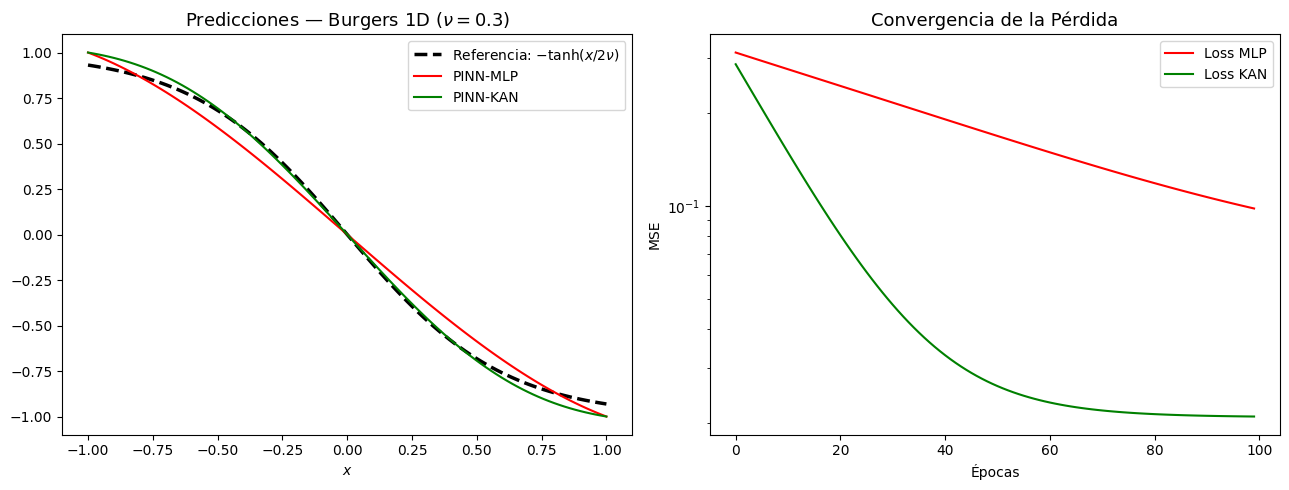

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# PROBLEMA: Burgers Estacionaria 1D — u·u_x = nu·u_xx, x in [-1,1]
# CC exactas impuestas por lifting: u = u_raw·(1-x²) + (-x)
# =============================================================
N     = 100
x     = np.linspace(-1, 1, N).reshape(-1, 1)   # (N,1)
nu    = 0.3                                       # viscosidad
u_exact = -np.tanh(x / (2*nu))                   # solución de referencia
epochs = 100
H     = 20

# --- Factor de anclaje y lifting para CCs exactas ---
f   = 1.0 - x**2            # (N,1)  factor: f(-1)=f(1)=0
fp  = -2.0 * x               # f'(x)
fpp = -2.0 * np.ones_like(x) # f''(x)
g   = -x                     # (N,1)  lifting: g(-1)=1, g(1)=-1
gp  = -1.0                   # g'(x) = -1

# =============================================================
# SECCIÓN A: PINN-MLP para Burgers
# =============================================================
np.random.seed(42)
W = np.random.randn(1, H) * 0.1
b = np.zeros((1, H))
V = np.random.randn(H, 1) * 0.1
lr_mlp = 0.005
loss_mlp = []

for epoch in range(epochs):
    # ---- FORWARD ----
    z    = x @ W + b
    a    = np.tanh(z)
    ap   = 1.0 - a**2
    app  = -2.0 * a * ap
    appp = -2.0 * ap * (1.0 - 3.0*a**2)

    # Derivadas de la red cruda
    u_raw   = a       @ V                     # (N,1)
    ux_raw  = (ap * W) @ V                    # (N,1)
    uxx_raw = (app * W**2) @ V                # (N,1)

    # Solución con lifting y sus derivadas
    u_pred = u_raw * f + g                                       # (N,1)
    u_x    = ux_raw * f + u_raw * fp + gp                        # (N,1)
    u_xx   = uxx_raw * f + 2.0*ux_raw*fp + u_raw*fpp            # (N,1)

    # ---- PÉRDIDA ----
    R = u_pred * u_x - nu * u_xx          # residuo de Burgers (N,1)
    L = np.mean(R**2)
    loss_mlp.append(float(L))

    # ---- BACKWARD (regla del producto: ∂R/∂θ = u_x·∂u/∂θ + u·∂u_x/∂θ - nu·∂u_xx/∂θ) ----

    # >> Respecto a V (V aparece linealmente en u_raw, ux_raw, uxx_raw)
    du_dV   = a * f                                # (N,H)  ∂u/∂Vj
    dux_dV  = ap*W * f + a * fp                    # (N,H)  ∂u_x/∂Vj
    duxx_dV = app*W**2 * f + 2.0*(ap*W)*fp + a*fpp# (N,H)  ∂u_xx/∂Vj
    d_R_dV  = u_x*du_dV + u_pred*dux_dV - nu*duxx_dV           # (N,H)
    grad_V  = (np.mean(2*R * d_R_dV, axis=0, keepdims=True)).T  # (H,1)

    # >> Respecto a b (∂z/∂b=1 → tanh''' aparece en ∂uxx_raw/∂b)
    du_db   = V.T * ap * f                              # (N,H)
    dux_db  = V.T * app * W * f + V.T * ap * fp         # (N,H)
    duxx_db = V.T * appp * W**2 * f + 2.0*V.T*app*W*fp + V.T*ap*fpp  # (N,H)
    d_R_db  = u_x*du_db + u_pred*dux_db - nu*duxx_db
    grad_b  = np.mean(2*R * d_R_db, axis=0, keepdims=True)      # (1,H)

    # >> Respecto a W (∂z/∂W=x → regla del producto doble + lifting)
    du_dW   = V.T * ap * x * f                                          # (N,H)
    dux_dW  = V.T * (ap + W*x*app) * f + V.T * ap * x * fp             # (N,H)
    duxx_dW = V.T * (2*W*app + W**2*x*appp) * f \
            + 2.0*V.T*(ap + W*x*app)*fp + V.T*ap*x*fpp                 # (N,H)
    d_R_dW  = u_x*du_dW + u_pred*dux_dW - nu*duxx_dW
    grad_W  = np.mean(2*R * d_R_dW, axis=0, keepdims=True)              # (1,H)

    W -= lr_mlp * grad_W
    b -= lr_mlp * grad_b
    V -= lr_mlp * grad_V

# =============================================================
# SECCIÓN B: PINN-KAN para Burgers (con todas las correcciones)
# =============================================================
np.random.seed(42)
C       = np.random.randn(H, 1) * 0.01             # (H,1) NO inicializar a cero
mu      = np.linspace(-1, 1, H).reshape(1, H)      # (1,H) centros en [-1,1]
log_sig = np.zeros((1, H))                          # (1,H) log(sigma) — garantiza sigma>0

lr_C    = 0.005
lr_mu   = 0.0005
lr_lsig = 0.0005
loss_kan = []

for epoch in range(epochs):
    sigma = np.exp(log_sig)         # (1,H) siempre positivo

    # ---- FORWARD ----
    z    = (x - mu) / sigma         # (N,H)
    z2   = z**2

    phi    = np.exp(-0.5 * z2)
    phi_x  = phi * (-z / sigma)
    phi_xx = phi * (z2 - 1.0) / sigma**2

    u_raw_k   = phi    @ C   # (N,1)
    ux_raw_k  = phi_x  @ C   # (N,1)
    uxx_raw_k = phi_xx @ C   # (N,1)

    # Solución con lifting
    u_pred_kan = u_raw_k * f + g
    u_x_kan    = ux_raw_k * f + u_raw_k * fp + gp
    u_xx_kan   = uxx_raw_k * f + 2.0*ux_raw_k*fp + u_raw_k*fpp

    # ---- PÉRDIDA ----
    R_k = u_pred_kan * u_x_kan - nu * u_xx_kan   # (N,1)
    L_k = np.mean(R_k**2)
    loss_kan.append(float(L_k))

    # ---- BACKWARD ----
    # Derivadas de u_raw_k, ux_raw_k, uxx_raw_k respecto a C:  phi, phi_x, phi_xx
    # Con lifting: ∂u/∂Cj = phi_j·f, ∂u_x/∂Cj = phi_x_j·f + phi_j·fp, etc.
    du_dC   = phi    * f                                       # (N,H)
    dux_dC  = phi_x  * f + phi    * fp                        # (N,H)
    duxx_dC = phi_xx * f + 2.0*phi_x*fp + phi*fpp             # (N,H)
    d_R_dC  = u_x_kan*du_dC + u_pred_kan*dux_dC - nu*duxx_dC # (N,H)
    grad_C  = (np.mean(2*R_k * d_R_dC, axis=0, keepdims=True)).T  # (H,1)

    # Derivadas auxiliares de phi, phi_x, phi_xx respecto a mu
    phi_mu    = phi    * ( z / sigma)
    phi_xmu   = phi    * (1.0 - z2) / sigma**2
    phi_xxmu  = phi    * (3.0*z - z**3) / sigma**3       # ← signo correcto

    # Derivadas de u, u_x, u_xx respecto a mu (usando lifting)
    du_dmu    = phi_mu   * C.T * f                                         # (N,H)
    dux_dmu   = phi_xmu  * C.T * f + phi_mu * C.T * fp                    # (N,H)
    duxx_dmu  = phi_xxmu * C.T * f + 2.0*phi_xmu*C.T*fp + phi_mu*C.T*fpp # (N,H)
    d_R_dmu   = u_x_kan*du_dmu + u_pred_kan*dux_dmu - nu*duxx_dmu
    grad_mu   = np.mean(2*R_k * d_R_dmu, axis=0, keepdims=True)           # (1,H)

    # Derivadas auxiliares de phi, phi_x, phi_xx respecto a sigma
    phi_sig    = phi    * (z2 / sigma)
    phi_xsig   = phi    * (2.0*z - z**3) / sigma**2
    phi_xxsig  = phi    * (z**4 - 5.0*z2 + 2.0) / sigma**3

    du_dsig    = phi_sig   * C.T * f
    dux_dsig   = phi_xsig  * C.T * f + phi_sig * C.T * fp
    duxx_dsig  = phi_xxsig * C.T * f + 2.0*phi_xsig*C.T*fp + phi_sig*C.T*fpp
    d_R_dsig   = u_x_kan*du_dsig + u_pred_kan*dux_dsig - nu*duxx_dsig
    grad_sig   = np.mean(2*R_k * d_R_dsig, axis=0, keepdims=True)         # (1,H)

    # Regla de la cadena log_sigma: grad_log_sigma = grad_sigma * sigma
    grad_lsig  = grad_sig * sigma    # (1,H)

    C       -= lr_C    * grad_C
    mu      -= lr_mu   * grad_mu
    log_sig -= lr_lsig * grad_lsig

# =============================================================
# VISUALIZACIÓN
# =============================================================
sigma_final = np.exp(log_sig)
print(f"Loss final MLP (Burgers):  {loss_mlp[-1]:.2e}")
print(f"Loss final KAN (Burgers):  {loss_kan[-1]:.2e}")
print(f"sigma_min = {sigma_final.min():.4f}, sigma_max = {sigma_final.max():.4f}  (todas > 0 ✓)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x, u_exact,    'k--', lw=2.5, label=r'Referencia: $-\tanh(x/2\nu)$')
axes[0].plot(x, u_pred,     'r-',  lw=1.5, label='PINN-MLP')
axes[0].plot(x, u_pred_kan, 'g-',  lw=1.5, label='PINN-KAN')
axes[0].set_title('Predicciones — Burgers 1D ($\\nu=0.3$)', fontsize=13)
axes[0].set_xlabel('$x$'); axes[0].legend()

axes[1].semilogy(loss_mlp, 'r-', lw=1.5, label='Loss MLP')
axes[1].semilogy(loss_kan, 'g-', lw=1.5, label='Loss KAN')
axes[1].set_title('Convergencia de la Pérdida', fontsize=13)
axes[1].set_xlabel('Épocas'); axes[1].set_ylabel('MSE'); axes[1].legend()

plt.tight_layout()
plt.show()
